In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [11]:
df = pd.read_excel("Datos/BD_IPSA_1940.xlsx")

In [45]:
display(df.head())

,Unnamed: 0,NOME,FAZ,TAL,tipocorte,variedad,madurada,producto,dosismad,semsmad,...,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea,Categoria_TCH,Categoria_Sacarosa
0,11,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,...,2.4,14.0,12,202012,112,137,3,6.2,Bajo,Alto
1,12,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,...,2.3,13.0,3,201903,157,0,3,3.5,Alto,Medio
2,13,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,...,1.8,13.3,3,202003,167,68,3,4.3,Alto,Alto
3,15,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,...,2.5,13.4,3,201903,156,0,3,3.5,Alto,Alto
4,16,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,...,2.1,14.0,3,202003,151,68,3,4.3,Medio,Alto


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          2187 non-null   int64  
 1   NOME                2187 non-null   object 
 2   FAZ                 2187 non-null   int64  
 3   TAL                 2187 non-null   object 
 4   tipocorte           2187 non-null   object 
 5   variedad            2187 non-null   object 
 6   madurada            2187 non-null   object 
 7   producto            2187 non-null   object 
 8   dosismad            2187 non-null   float64
 9   semsmad             2187 non-null   float64
 10  edad                2187 non-null   float64
 11  cortes              2187 non-null   int64  
 12  me                  2187 non-null   float64
 13  vejez               2187 non-null   float64
 14  sacarosa            2187 non-null   float64
 15  mes                 2187 non-null   int64  
 16  period

In [17]:
print(df.describe())

        Unnamed: 0           FAZ     dosismad      semsmad         edad  \
count  2187.000000   2187.000000  2187.000000  2187.000000  2187.000000   
mean   2126.506630  80588.332876     0.993278     9.164838    12.766118   
std    1228.561661    572.818299     0.309096     3.441579     1.117866   
min      11.000000  80100.000000     0.000000    -1.600000    10.300000   
25%    1038.000000  80222.000000     0.800000     7.100000    12.000000   
50%    2219.000000  80396.000000     1.000000     8.700000    12.500000   
75%    3223.500000  80660.000000     1.200000    10.600000    13.300000   
max    4222.000000  82519.000000     9.000000    45.000000    21.100000   

            cortes           me        vejez     sacarosa          mes  \
count  2187.000000  2187.000000  2187.000000  2187.000000  2187.000000   
mean      2.794239     9.197759     4.172154    12.777732     6.758573   
std       1.621195     1.574409     6.339255     0.854397     3.482444   
min       1.000000     3.400

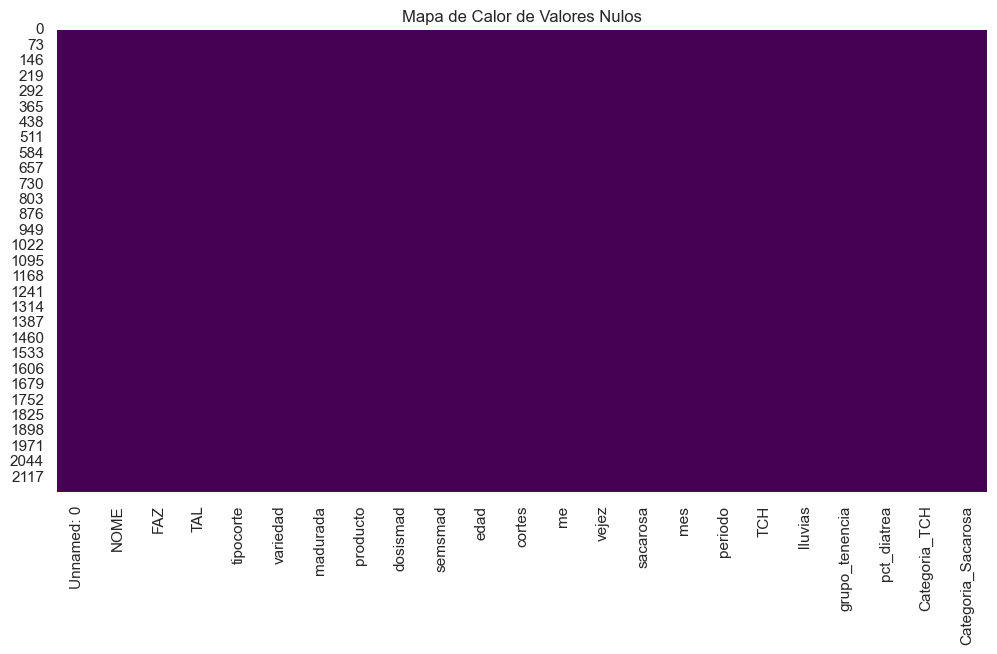

Unnamed: 0            0.0
me                    0.0
Categoria_TCH         0.0
pct_diatrea           0.0
grupo_tenencia        0.0
lluvias               0.0
TCH                   0.0
periodo               0.0
mes                   0.0
sacarosa              0.0
vejez                 0.0
cortes                0.0
NOME                  0.0
edad                  0.0
semsmad               0.0
dosismad              0.0
producto              0.0
madurada              0.0
variedad              0.0
tipocorte             0.0
TAL                   0.0
FAZ                   0.0
Categoria_Sacarosa    0.0
dtype: float64

In [49]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de Calor de Valores Nulos")
plt.show()

# Porcentaje de nulos
faltantes = df.isnull().mean().sort_values(ascending=False) * 100
display(faltantes)

In [51]:
columnas_a_eliminar = faltantes[faltantes > 40].index
df = df.drop(columns=columnas_a_eliminar)
print(f"Columnas eliminadas: {list(columnas_a_eliminar)}")

Columnas eliminadas: []


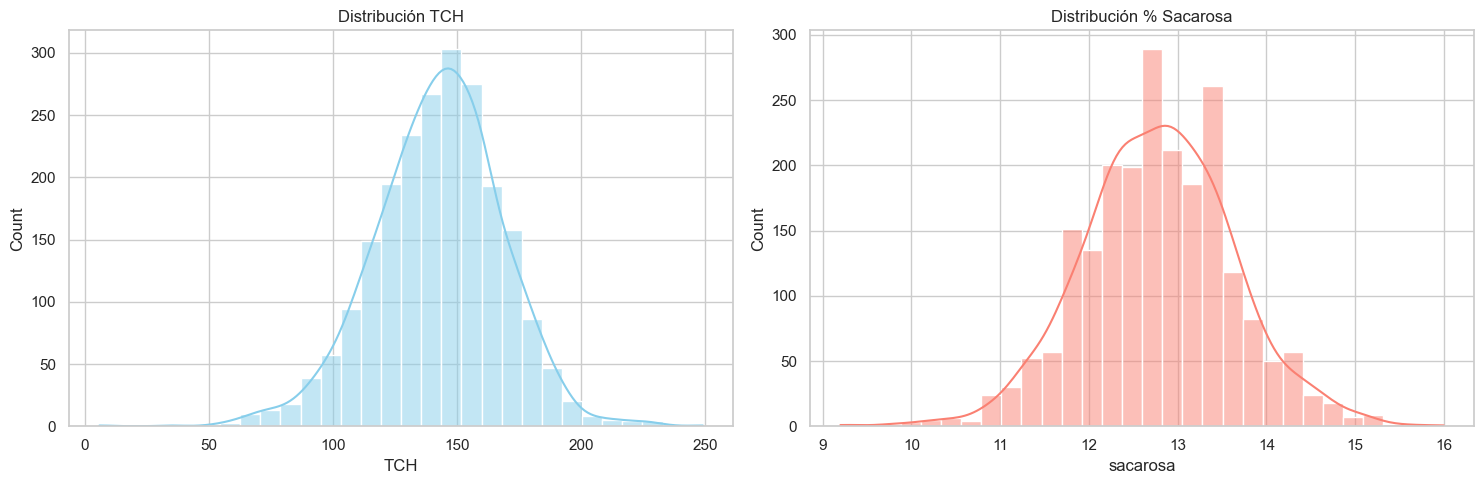

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['TCH'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución TCH')

sns.histplot(df['sacarosa'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución % Sacarosa')

plt.tight_layout()
plt.show()


In [55]:
# Umbrales para TCH
q_tch = np.percentile(df['TCH'], [33.3, 66.6])
print(f"Umbrales TCH -> Bajo: <= {q_tch[0]:.2f}, Medio: <= {q_tch[1]:.2f}, Alto: > {q_tch[1]:.2f}")

# Umbrales para sacarosa
q_sac = np.percentile(df['sacarosa'], [33.3, 66.6])
print(f"Umbrales Sacarosa -> Bajo: <= {q_sac[0]:.2f}, Medio: <= {q_sac[1]:.2f}, Alto: > {q_sac[1]:.2f}")

Umbrales TCH -> Bajo: <= 133.00, Medio: <= 153.00, Alto: > 153.00
Umbrales Sacarosa -> Bajo: <= 12.40, Medio: <= 13.10, Alto: > 13.10


In [57]:
def categorizar_tch(valor):
    if valor <= q_tch[0]:
        return 'Bajo'
    elif valor <= q_tch[1]:
        return 'Medio'
    else:
        return 'Alto'

def categorizar_sacarosa(valor):
    if valor <= q_sac[0]:
        return 'Bajo'
    elif valor <= q_sac[1]:
        return 'Medio'
    else:
        return 'Alto'

In [59]:
df['Categoria_TCH'] = df['TCH'].apply(categorizar_tch)
df['Categoria_Sacarosa'] = df['sacarosa'].apply(categorizar_sacarosa)

df[['TCH', 'Categoria_TCH', 'sacarosa', 'Categoria_Sacarosa']].head()

,TCH,Categoria_TCH,sacarosa,Categoria_Sacarosa
0,112,Bajo,14.0,Alto
1,157,Alto,13.0,Medio
2,167,Alto,13.3,Alto
3,156,Alto,13.4,Alto
4,151,Medio,14.0,Alto


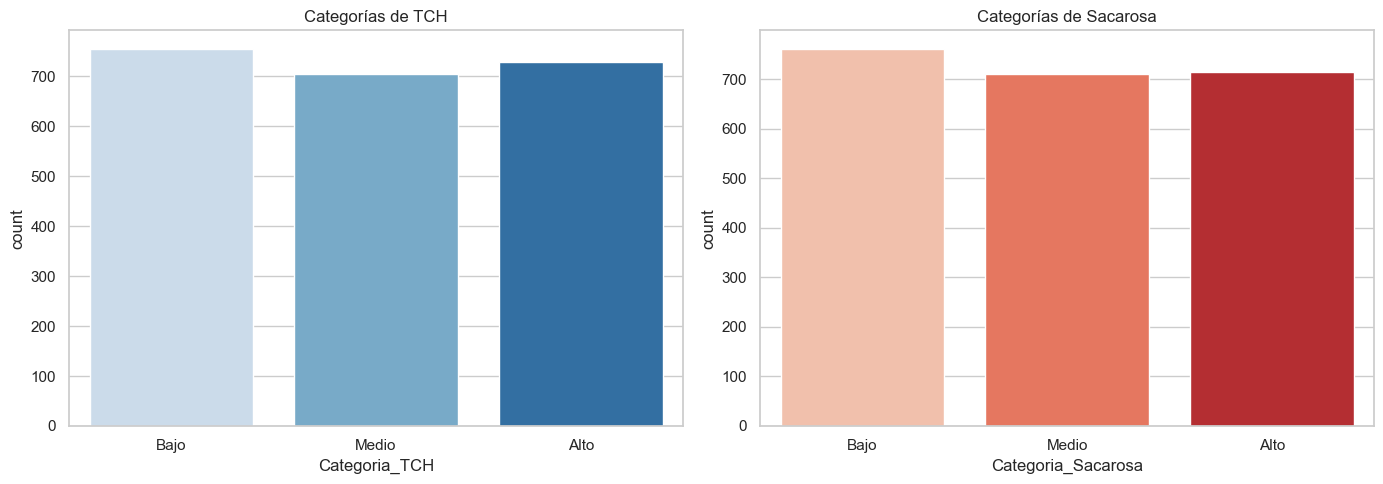

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Categoria_TCH', data=df, order=['Bajo', 'Medio', 'Alto'], ax=axes[0], palette='Blues')
axes[0].set_title('Categorías de TCH')

sns.countplot(x='Categoria_Sacarosa', data=df, order=['Bajo', 'Medio', 'Alto'], ax=axes[1], palette='Reds')
axes[1].set_title('Categorías de Sacarosa')

plt.tight_layout()
plt.show()

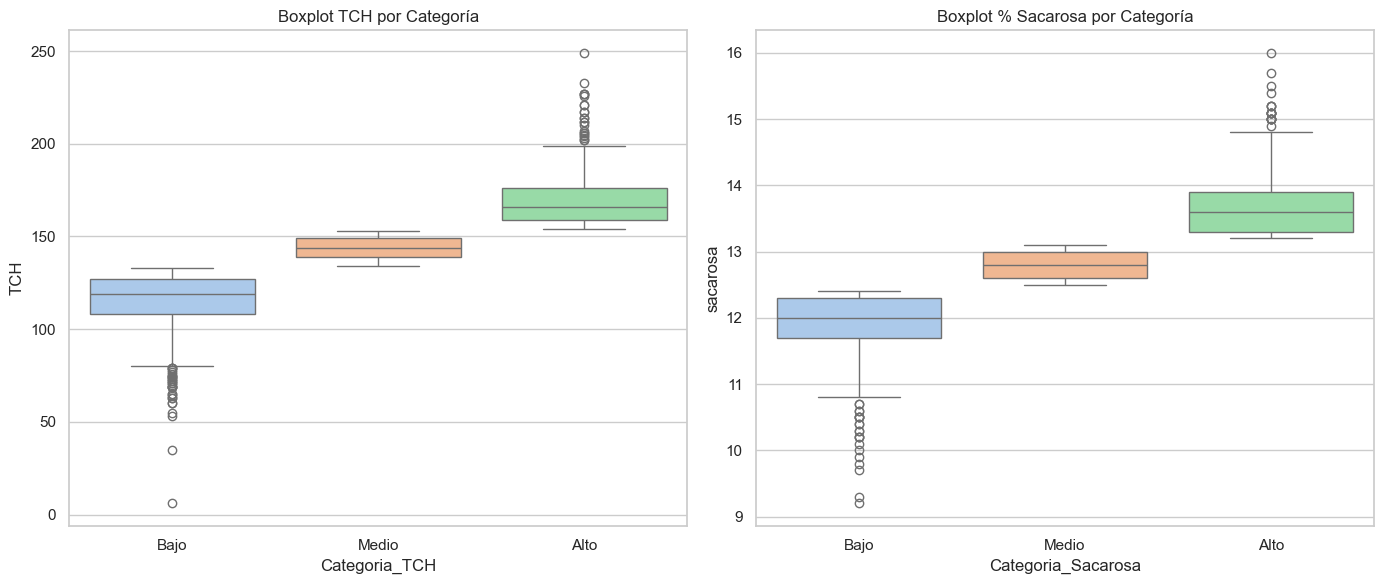

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='Categoria_TCH', y='TCH', data=df, order=['Bajo', 'Medio', 'Alto'], palette='pastel', ax=axes[0])
axes[0].set_title('Boxplot TCH por Categoría')

sns.boxplot(x='Categoria_Sacarosa', y='sacarosa', data=df, order=['Bajo', 'Medio', 'Alto'], palette='pastel', ax=axes[1])
axes[1].set_title('Boxplot % Sacarosa por Categoría')

plt.tight_layout()
plt.show()

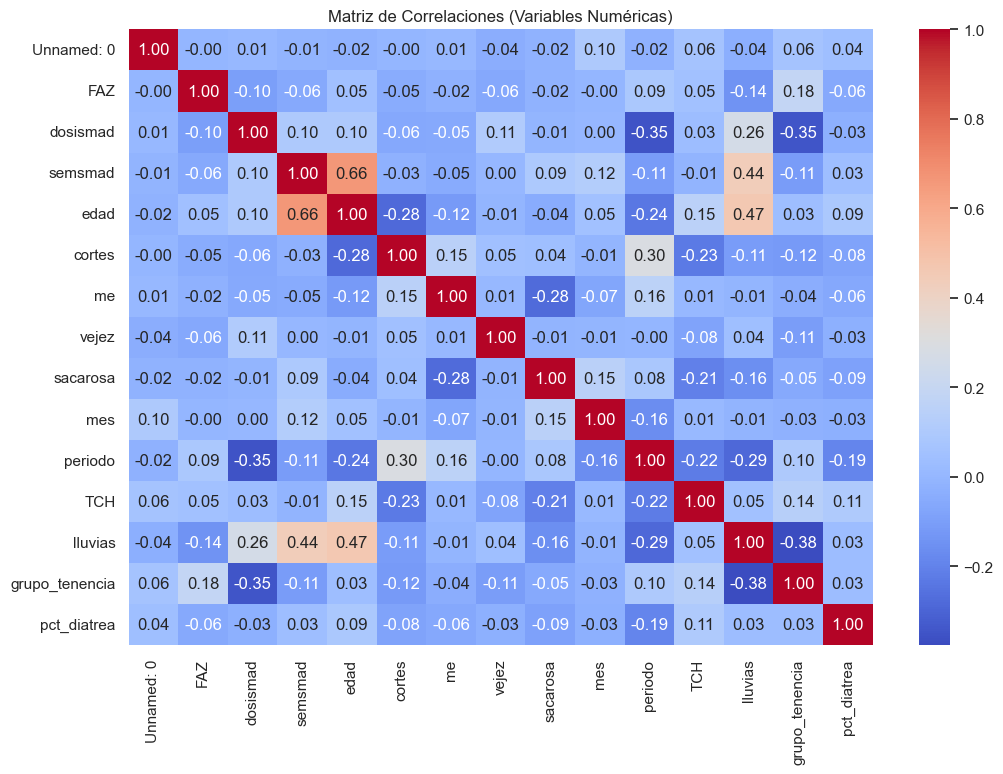

In [65]:
# Solo columnas numéricas para evitar error
num_cols = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 8))
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlaciones (Variables Numéricas)')
plt.show()

In [69]:
df.to_csv('Datos/BD_IPSA_Clasificada.csv', index=False)
print('Archivo con categorías guardado como BD_IPSA_Clasificada.csv')

Archivo con categorías guardado como BD_IPSA_Clasificada.csv
